# XGBoost Experiments
This notebook is a lightweight sandbox for primitive test runs using XGBoost.
Run cells in order from top to bottom.

In [98]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import importlib
import preprocessing_NLP
importlib.reload(preprocessing_NLP)
from preprocessing_NLP import build_raw_dataset_nlp
from preprocessing import load_all_data

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"
TWEETS_FILE = "tweets.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

TEXT_COLUMN = "text"

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "reply_count", "favorite_count", "num_urls", "num_mentions"
]

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 12,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.3,
    "eval_metric": "logloss",
    "use_label_encoder": False,
    "random_state": 42,
}

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))
print("XGBoost version:", xgb.__version__)

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9
XGBoost version: 3.2.0


In [99]:
# Block 1: Data loading (full configured datasets)
raw = build_raw_dataset_nlp(
    DATASETS,
    BASE_DIR,
    TWEET_FEATURES,
    TWEETS_FILE
)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368


In [100]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

numeric_tweet_features = [c for c in TWEET_FEATURES if c != "text" and c in raw.columns]
X = pd.concat([X, raw[numeric_tweet_features]], axis=1)
X = X.fillna(0)

if "text" in raw.columns:
    X["text"] = raw["text"].fillna("").astype(str)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Numeric features:", [c for c in X.columns if c != "text"])
print("Shape:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Numeric features: ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'verified', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions']
Shape: (14368, 13)
Train shape: (11494, 13)
Test shape: (2874, 13)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64
scale_pos_weight: 0.3189


In [ ]:
# Block 3: Training
from sklearn.preprocessing import MaxAbsScaler

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
text_train = tfidf.fit_transform(X_train["text"])
text_test  = tfidf.transform(X_test["text"])

num_cols = [c for c in X_train.columns if c != "text"]
X_train_num = X_train[num_cols].values.astype(np.float32)
X_test_num  = X_test[num_cols].values.astype(np.float32)

scaler = MaxAbsScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

X_train_final = sp.hstack([X_train_num, text_train])
X_test_final  = sp.hstack([X_test_num,  text_test])

tfidf_feature_names = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
all_feature_names = num_cols + tfidf_feature_names

print(f"Final train matrix: {X_train_final.shape}")
print(f"Final test matrix:  {X_test_final.shape}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8, 
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    verbose=50,
)

booster = model.get_booster()
booster.feature_names = all_feature_names

print("\nTraining complete.")
if hasattr(model, 'best_iteration') and model.best_iteration is not None:
    print("Best iteration:", model.best_iteration)
else:
    print("No early stopping used. Total rounds:", model.n_estimators)

Final train matrix: (11494, 2012)
Final test matrix:  (2874, 2012)
[0]	validation_0-logloss:0.60278
[50]	validation_0-logloss:0.02341
[100]	validation_0-logloss:0.01662
[150]	validation_0-logloss:0.01591
[200]	validation_0-logloss:0.01612
[250]	validation_0-logloss:0.01624
[299]	validation_0-logloss:0.01646

Training complete.
No early stopping used. Total rounds: 300


In [102]:
# Block 4: Evaluation
pred = model.predict(X_test_final, validate_features=False)
pred_proba = model.predict_proba(X_test_final, validate_features=False)[:, 1]

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred_proba):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

print("AUPRC:", round(average_precision_score(y_test, pred_proba), 4))

importance_df = (
    pd.DataFrame(
        model.get_booster().get_score(importance_type="gain"),
        index=["gain"]
    )
    .T.rename_axis("feature").reset_index()
    .sort_values("gain", ascending=False)
)

print("\nTop 20 features by gain:")
display(importance_df.head(20))

missed_bots_indices = (y_test == 1) & (pred == 0)

missed_bots_data = X_test[missed_bots_indices]

print(f"Number of missed bots: {len(missed_bots_data)}")
display(missed_bots_data)

# y_probs = model.predict_proba(X_test)[:, 1]

# missed_probs = y_probs[missed_bots_indices]
# print("Model confidence for missed bots:", missed_probs)

accuracy:          0.9955
balanced_accuracy: 0.9941
f1_macro:          0.9938
roc_auc:           0.9997
AUPRC:             0.9999

Confusion Matrix:
[[ 689    6]
 [   7 2172]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9914    0.9907       695
           1     0.9972    0.9968    0.9970      2179

    accuracy                         0.9955      2874
   macro avg     0.9936    0.9941    0.9938      2874
weighted avg     0.9955    0.9955    0.9955      2874

AUPRC: 0.9999

Top 20 features by gain:


,feature,gain
3,favourites_count,49.942066
11,tfidf_http,20.159582
10,num_mentions,18.944704
9,num_urls,15.310190
8,favorite_count,15.142483
0,statuses_count,6.116164
7,reply_count,1.537631
2,friends_count,1.249746
4,listed_count,1.161337
1,followers_count,0.974623


Number of missed bots: 7


,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,verified,reply_count,favorite_count,num_urls,num_mentions,text
13896,10306,930,562,0,29,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,
12862,9298,396,133,49,9,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,
13237,42572,424,420,77,27,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,
6364,67,22,668,5,0,1.0,0.0,0.0,0.029851,0.000000,0.000000,0.0,if i haven't fallowed you back please mention...
13239,51696,408,315,114,56,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,
13057,6264,65,223,10,14,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,
11477,6470,856,1591,1507,2,0.0,0.0,0.0,0.000000,0.041589,0.297952,0.0,"Our best psychics, joining in from all over t..."


In [103]:
# Block 5: Feature importance list
importance = model.get_booster().get_score(importance_type="gain")
importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

print("Top 20 Features — XGBoost (gain):")
for i, (feature, score) in enumerate(importance_sorted[:20], 1):
    print(f"  {i:2}. {feature:<35} {score:.4f}")

Top 20 Features — XGBoost (gain):
   1. favourites_count                    49.9421
   2. tfidf_http                          20.1596
   3. num_mentions                        18.9447
   4. num_urls                            15.3102
   5. favorite_count                      15.1425
   6. statuses_count                      6.1162
   7. reply_count                         1.5376
   8. friends_count                       1.2497
   9. listed_count                        1.1613
  10. followers_count                     0.9746
  11. default_profile_image               0.9002
  12. default_profile                     0.5617


In [104]:
# Block 6: Save model
MODEL_PATH = "xgboost_bot_detector.json"
model.save_model(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to xgboost_bot_detector.json


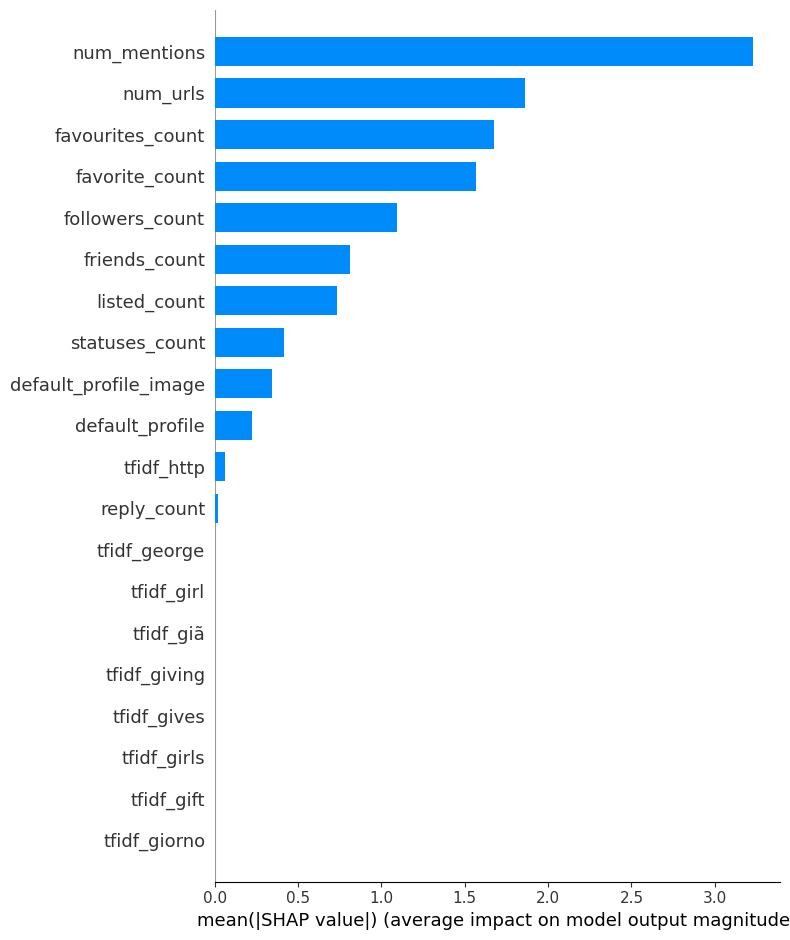

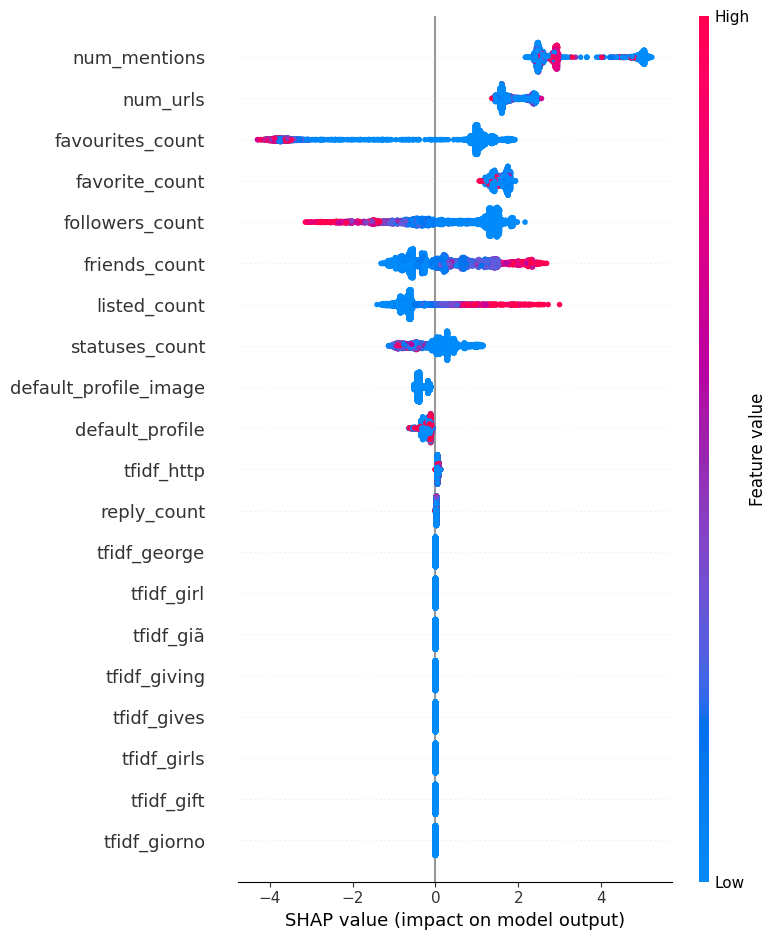

In [105]:
import shap
import scipy.sparse as sp

X_test_dense = X_test_final.toarray()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_dense)

shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names, plot_type="bar")

shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names)

XGBoost LOBO Results:


,held_out_bot_source,test_rows,bot_support,genuine_support,auprc,precision_bot,recall_bot,accuracy
0,traditional_spambots_3.csv,1098,403,695,0.757582,0.984848,0.322581,0.749545
1,traditional_spambots_2.csv,795,100,695,0.951951,0.935484,0.580000,0.942138
2,social_spambots_3.csv,1159,464,695,0.982610,0.984127,0.400862,0.757550
3,fake_followers.csv,4046,3351,695,0.998127,0.998709,0.692331,0.744439
4,traditional_spambots_4.csv,1823,1128,695,0.999592,0.997235,0.959220,0.973121
5,social_spambots_2.csv,4152,3457,695,0.999931,0.998554,0.999132,0.998073
6,social_spambots_1.csv,1686,991,695,0.999971,0.997978,0.995964,0.996441
7,traditional_spambots_1.csv,1695,1000,695,0.999984,0.997003,0.998000,0.997050



LOBO macro-average (mean ± std):
                 auprc: 0.9612 ± 0.0840
         precision_bot: 0.9867 ± 0.0216
            recall_bot: 0.7435 ± 0.2839
              accuracy: 0.8948 ± 0.1209


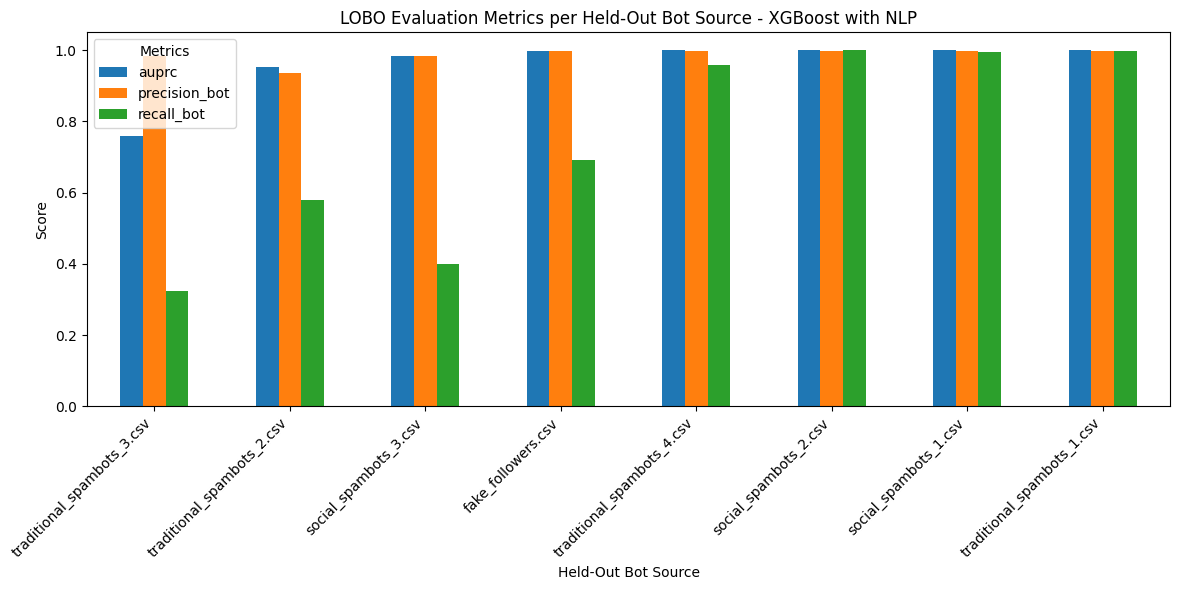

In [ ]:
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score
)
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
import pandas as pd
import numpy as np

entity_key = raw["source_file"].astype(str) + "::" + raw.index.astype(str)


genuine_source = "genuine_accounts.csv"
genuine_mask = raw["source_file"] == genuine_source
genuine_idx = raw.index[genuine_mask].to_numpy()
genuine_groups = entity_key.loc[genuine_idx]

gss_genuine = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
genuine_train_rel, genuine_test_rel = next(
    gss_genuine.split(X.loc[genuine_idx], y.loc[genuine_idx], groups=genuine_groups)
)
genuine_train_idx = genuine_idx[genuine_train_rel]
genuine_test_idx = genuine_idx[genuine_test_rel]

bot_sources = sorted([
    source for source, label in DATASETS.items()
    if label == 1 and (raw["source_file"] == source).any()
])

lobo_rows = []
for held_out_bot_source in bot_sources:
    held_out_bot_idx = raw.index[raw["source_file"] == held_out_bot_source].to_numpy()
    train_bot_idx = raw.index[(raw["label"] == 1) & (raw["source_file"] != held_out_bot_source)].to_numpy()

    train_idx = np.concatenate([genuine_train_idx, train_bot_idx])
    test_idx = np.concatenate([genuine_test_idx, held_out_bot_idx])

    X_lobo_train = X.loc[train_idx]
    y_lobo_train = y.loc[train_idx]
    X_lobo_test = X.loc[test_idx]
    y_lobo_test = y.loc[test_idx]

    neg = (y_lobo_train == 0).sum()
    pos = (y_lobo_train == 1).sum()
    
    X_lobo_train = X_lobo_train.select_dtypes(include=[np.number])
    X_lobo_test = X_lobo_test.select_dtypes(include=[np.number])

    lobo_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        scale_pos_weight=neg/pos,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    lobo_model.fit(X_lobo_train, y_lobo_train)

    lobo_pred = lobo_model.predict(X_lobo_test)
    lobo_proba = lobo_model.predict_proba(X_lobo_test)[:, 1]

    lobo_rows.append({
        "held_out_bot_source": held_out_bot_source,
        "test_rows": int(len(test_idx)),
        "bot_support": int((y_lobo_test == 1).sum()),
        "genuine_support": int((y_lobo_test == 0).sum()),
        "auprc": average_precision_score(y_lobo_test, lobo_proba),
        "precision_bot": precision_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
        "recall_bot": recall_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_lobo_test, lobo_pred),
        # "balanced_accuracy": balanced_accuracy_score(y_lobo_test, lobo_pred),
    })

lobo_results = pd.DataFrame(lobo_rows).sort_values("auprc", ascending=True).reset_index(drop=True)
print("XGBoost LOBO Results:")
display(lobo_results)

summary_cols = ["auprc", "precision_bot", "recall_bot", "accuracy"]# "balanced_accuracy"]
print("\nLOBO macro-average (mean ± std):")
for col in summary_cols:
    print(f"  {col:>20}: {lobo_results[col].mean():.4f} ± {lobo_results[col].std():.4f}")
    
    import matplotlib.pyplot as plt

df_plot = lobo_results.set_index("held_out_bot_source")

metrics_to_plot = ["auprc", "precision_bot", "recall_bot"] #, "balanced_accuracy"]

ax = df_plot[metrics_to_plot].plot(kind="bar", figsize=(12, 6))

plt.title("LOBO Evaluation Metrics per Held-Out Bot Source - XGBoost with NLP")
plt.xlabel("Held-Out Bot Source")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Run Order
1. Cell 1: imports and constants
2. Cell 2: helper functions
3. Cell 3: full data loading
4. Cell 4: slicing and preprocessing
5. Cell 5: training
6. Cell 6: evaluation
7. Cell 7: feature importance list
8. Cell 8: save model